<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/An_Explainable%2C_Fair%2C_and_Calibrated_Machine_Learning_Framework_for_Heart_Disease_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Abstract

Heart disease remains one of the leading causes of mortality worldwide, highlighting the need for accurate and reliable predictive models to support early diagnosis and clinical decision-making. This study presents a comprehensive and trustworthy machine learning framework for heart disease risk prediction by integrating statistical analysis, explainable artificial intelligence (XAI), fairness assessment, and uncertainty quantification. Initially, exploratory data analysis and statistical hypothesis testing, including Chi-square tests, independent t-tests, and Pearson correlation analysis, were performed to investigate the relationships between clinical variables and heart disease risk. The dataset was partitioned into training, validation, and testing subsets using a 70:15:15 stratified split to preserve class distribution. Eight supervised machine learning models, namely Logistic Regression, Random Forest, XGBoost, LightGBM, Support Vector Machine (SVM), CatBoost, Gradient Boosting, and a Weighted Voting Ensemble, were developed and evaluated. Feature standardization was applied to scale-sensitive models, while tree-based models were trained on the original feature space. Model performance was assessed using accuracy, precision, recall, F1-score, receiver operating characteristic area under the curve (ROC-AUC), confusion matrices, and precision-recall curves. Model robustness was further validated through 10-fold stratified cross-validation. Among all evaluated classifiers, LightGBM achieved the highest predictive performance, obtaining an accuracy of 99.324% and a ROC-AUC of 0.99967 on the independent test set. To improve model transparency, SHAP (SHapley Additive exPlanations) was employed to identify the most influential clinical features contributing to heart disease prediction. Furthermore, fairness analysis across gender and age groups demonstrated consistent predictive performance with minimal demographic bias. Finally, isotonic probability calibration was applied to quantify prediction uncertainty, leading to a reduced Brier Score from 0.00553 to 0.00545, indicating improved probability calibration. The proposed framework demonstrates that combining high-performance machine learning with explainability, fairness evaluation, and calibrated uncertainty provides a robust and clinically interpretable decision-support system for heart disease risk prediction.




In [9]:
# ─── Install Dependencies ───
!pip install -q xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [10]:
# ─── Imports ───
import warnings, time, gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# ─── Plot Configuration ───
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})
SEED = 42
np.random.seed(SEED)

print("Environment ready.")

Environment ready.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Dataset/heart_disease_risk_dataset_earlymed.csv')
df.head()



Mounted at /content/drive


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [3]:
print("Dataset Shape:", df.shape)
print("\nTarget Distribution:\n", df['Heart_Risk'].value_counts(normalize=True))
print("\nGender Distribution:\n", df['Gender'].value_counts())
print("\nAge Statistics:\n", df['Age'].describe())

Dataset Shape: (70000, 19)

Target Distribution:
 Heart_Risk
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

Gender Distribution:
 Gender
1.0    38425
0.0    31575
Name: count, dtype: int64

Age Statistics:
 count    70000.000000
mean        54.461986
std         16.410794
min         20.000000
25%         45.000000
50%         56.000000
75%         67.000000
max         84.000000
Name: Age, dtype: float64


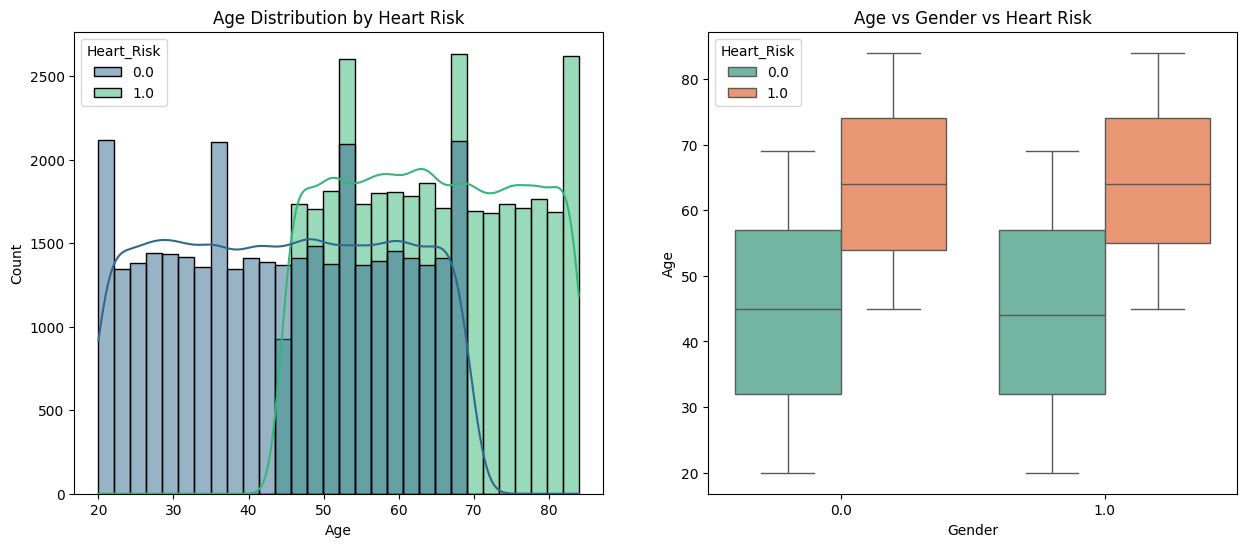

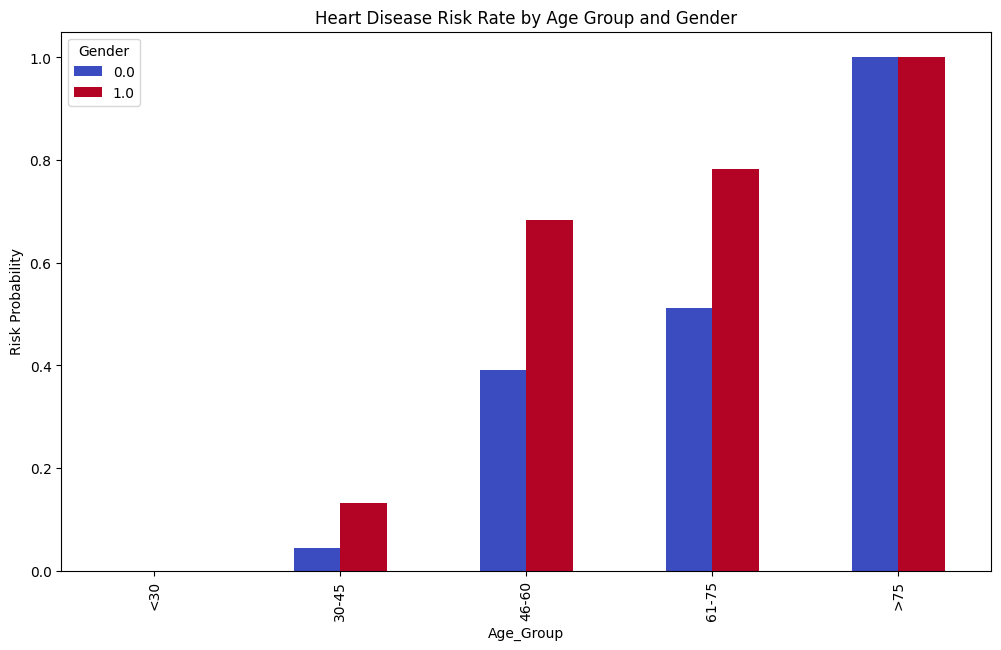

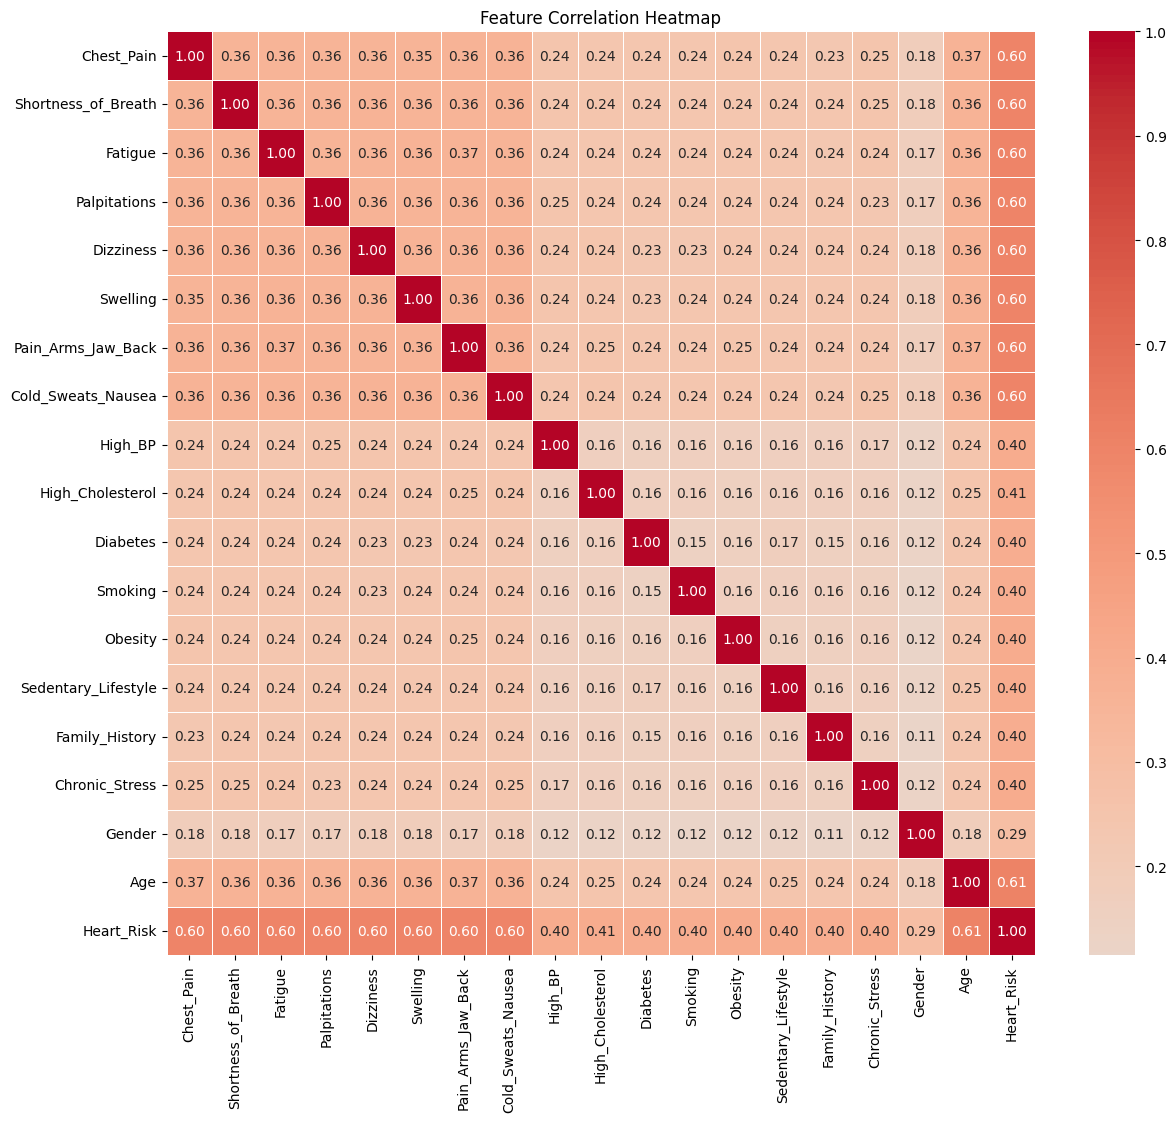

In [4]:
# 1. Age Distribution
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='Heart_Risk', bins=30, kde=True, palette='viridis')
plt.title('Age Distribution by Heart Risk')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Gender', y='Age', hue='Heart_Risk', palette='Set2')
plt.title('Age vs Gender vs Heart Risk')
plt.show()

# 2. Risk by Age Group & Gender
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 45, 60, 75, 100],
                        labels=['<30', '30-45', '46-60', '61-75', '>75'])

risk_by_group = df.groupby(['Age_Group', 'Gender'])['Heart_Risk'].mean().unstack()
risk_by_group.plot(kind='bar', colormap='coolwarm', figsize=(12, 7))
plt.title('Heart Disease Risk Rate by Age Group and Gender')
plt.ylabel('Risk Probability')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(14, 12))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [5]:
# ====================== STATISTICAL TESTS ======================
print("=== STATISTICAL TESTS RESULTS ===")
from scipy import stats

# 1. Chi-square Test: Gender vs Heart Risk
print("\n1. Gender vs Heart Risk (Chi-square Test):")
contingency_gender = pd.crosstab(df['Gender'], df['Heart_Risk'])
chi2_g, p_g, dof_g, expected_g = stats.chi2_contingency(contingency_gender)
print(f"Chi2 Statistic = {chi2_g:.2f}")
print(f"p-value = {p_g:.4e}")
print("→ Significant" if p_g < 0.05 else "→ Not Significant")

# 2. T-test: Age difference between Risk Groups
print("\n2. Age by Heart Risk Group (Independent T-test):")
age_no_risk = df[df['Heart_Risk'] == 0]['Age']
age_risk = df[df['Heart_Risk'] == 1]['Age']
t_stat, p_age = stats.ttest_ind(age_no_risk, age_risk)
print(f"T-statistic = {t_stat:.4f}")
print(f"p-value = {p_age:.4e}")
print("→ Significant" if p_age < 0.05 else "→ Not Significant")

# 3. Chi-square Tests for Important Categorical Features
print("\n3. Association of Key Features with Heart Risk:")
cat_features = ['Chest_Pain', 'High_BP', 'Diabetes', 'Smoking',
                'Obesity', 'Family_History', 'Gender']

for feature in cat_features:
    if feature in df.columns:
        contingency = pd.crosstab(df[feature], df['Heart_Risk'])
        chi2, p, _, _ = stats.chi2_contingency(contingency)
        significance = "Significant" if p < 0.05 else "Not Significant"
        print(f"  {feature:20} → p-value = {p:.4e} → {significance}")

# 4. Pearson Correlation Significance (Age)
print("\n4. Age vs Heart Risk (Pearson Correlation):")
corr, p_corr = stats.pearsonr(df['Age'], df['Heart_Risk'])
print(f"Correlation = {corr:.4f}")
print(f"p-value = {p_corr:.4e}")

=== STATISTICAL TESTS RESULTS ===

1. Gender vs Heart Risk (Chi-square Test):
Chi2 Statistic = 6033.26
p-value = 0.0000e+00
→ Significant

2. Age by Heart Risk Group (Independent T-test):
T-statistic = -201.1259
p-value = 0.0000e+00
→ Significant

3. Association of Key Features with Heart Risk:
  Chest_Pain           → p-value = 0.0000e+00 → Significant
  High_BP              → p-value = 0.0000e+00 → Significant
  Diabetes             → p-value = 0.0000e+00 → Significant
  Smoking              → p-value = 0.0000e+00 → Significant
  Obesity              → p-value = 0.0000e+00 → Significant
  Family_History       → p-value = 0.0000e+00 → Significant
  Gender               → p-value = 0.0000e+00 → Significant

4. Age vs Heart Risk (Pearson Correlation):
Correlation = 0.6052
p-value = 0.0000e+00


In [6]:
X = df.drop(['Heart_Risk', 'Age_Group'], axis=1)
y = df['Heart_Risk']

# Split 1: 30% goes to temp (leaves exactly 70% for train)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y, shuffle=True
)

# Split 2: 50% of temp goes to test (0.30 * 0.50 = 15% test, 15% val)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp, shuffle=True
)

print(f"Train: {X_train.shape[0]:,} ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]:,} ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test: {X_test.shape[0]:,} ({X_test.shape[0]/len(df)*100:.1f}%)")

Train: 49,000 (70.0%)
Validation: 10,500 (15.0%)
Test: 10,500 (15.0%)


In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Base Models
rf = RandomForestClassifier(n_estimators=400, max_depth=12, random_state=42, n_jobs=-1)
xgb_model = xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=8,
                              random_state=42, eval_metric='auc')
lgb_model = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=8,
                               random_state=42, verbose=-1)

#  Weighted Voting Ensemble
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb_model), ('lgb', lgb_model)],
    voting='soft',
    weights=[1, 2, 3]  # LightGBM gets highest weight
)

# All Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": rf,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
     "SVM (RBF)":SVC(kernel="rbf", C=10, gamma="scale", probability=True),
    "CatBoost": CatBoostClassifier(iterations=400, learning_rate=0.05, depth=8,
                                   random_state=42, verbose=False),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=400,
                                                     learning_rate=0.05, max_depth=8, random_state=42),
    "Ensemble (Weighted Voting)": ensemble
}

In [13]:
results = []

for name, model in models.items():

    print(f"Training {name}...")

    # Models that require scaling
    if name in ["Logistic Regression", "SVM (RBF)"]:
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Tree-based models (no scaling)
    else:
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1_Score": f1_score(y_test, y_pred, average="weighted")
    })

results_df = pd.DataFrame(results).round(5)

print(results_df.sort_values("ROC_AUC", ascending=False))

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training SVM (RBF)...
Training CatBoost...
Training Gradient Boosting...
Training Ensemble (Weighted Voting)...
                        Model  Accuracy  ROC_AUC  Precision   Recall  F1_Score
3                    LightGBM   0.99324  0.99967    0.99324  0.99324   0.99324
5                    CatBoost   0.99324  0.99965    0.99324  0.99324   0.99324
6           Gradient Boosting   0.99248  0.99965    0.99248  0.99248   0.99248
2                     XGBoost   0.99276  0.99964    0.99277  0.99276   0.99276
7  Ensemble (Weighted Voting)   0.99314  0.99964    0.99315  0.99314   0.99314
1               Random Forest   0.99238  0.99959    0.99239  0.99238   0.99238
0         Logistic Regression   0.99257  0.99959    0.99257  0.99257   0.99257
4                   SVM (RBF)   0.98933  0.99936    0.98933  0.98933   0.98933


In [14]:
# ─── 5-Fold Stratified Cross-Validation on Best Model ───

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

SEED = 42

# Select best model based on ROC-AUC (recommended)
best_idx = results_df['ROC_AUC'].idxmax()
best_name = results_df.loc[best_idx, "Model"]

print("="*60)
print(f"Best Model Selected : {best_name}")
print(f"Test Accuracy       : {results_df.loc[best_idx, 'Accuracy']:.5f}")
print(f"Test ROC-AUC        : {results_df.loc[best_idx, 'ROC_AUC']:.5f}")
print("="*60)

# Get the corresponding model
best_model = models[best_name]

# Apply scaling only for Logistic Regression and SVM
if best_name in ["Logistic Regression", "SVM (RBF)"]:
    best_model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", best_model)
    ])

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print(f"5-Fold CV Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("\nPer-Fold Accuracy:")
print(np.round(cv_scores, 5))

Best Model Selected : LightGBM
Test Accuracy       : 0.99324
Test ROC-AUC        : 0.99967
5-Fold CV Accuracy : 0.9920 ± 0.0015

Per-Fold Accuracy:
[0.99306 0.98918 0.99194 0.99255 0.99337]


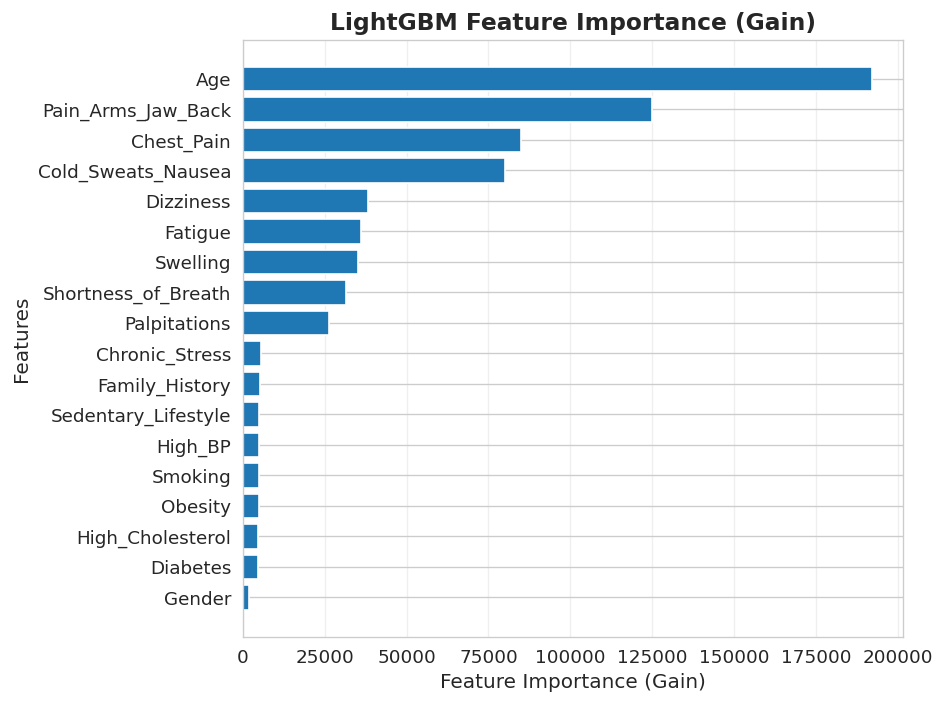

In [15]:
# =====================================================
# LightGBM Feature Importance (Gain)
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

best_model = models["LightGBM"]

importance = best_model.booster_.feature_importance(
    importance_type='gain'
)

feature_names = X_train.columns

fi = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

fi = fi.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,6))

plt.barh(
    fi['Feature'],
    fi['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance (Gain)", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.title(
    "LightGBM Feature Importance (Gain)",
    fontsize=14,
    fontweight='bold'
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

,Feature,Importance (%)
17,Age,27.791344
6,Pain_Arms_Jaw_Back,18.070100
0,Chest_Pain,12.281448
7,Cold_Sweats_Nausea,11.574733
4,Dizziness,5.527372
2,Fatigue,5.240202
5,Swelling,5.085636
1,Shortness_of_Breath,4.557399
3,Palpitations,3.797967
15,Chronic_Stress,0.811983


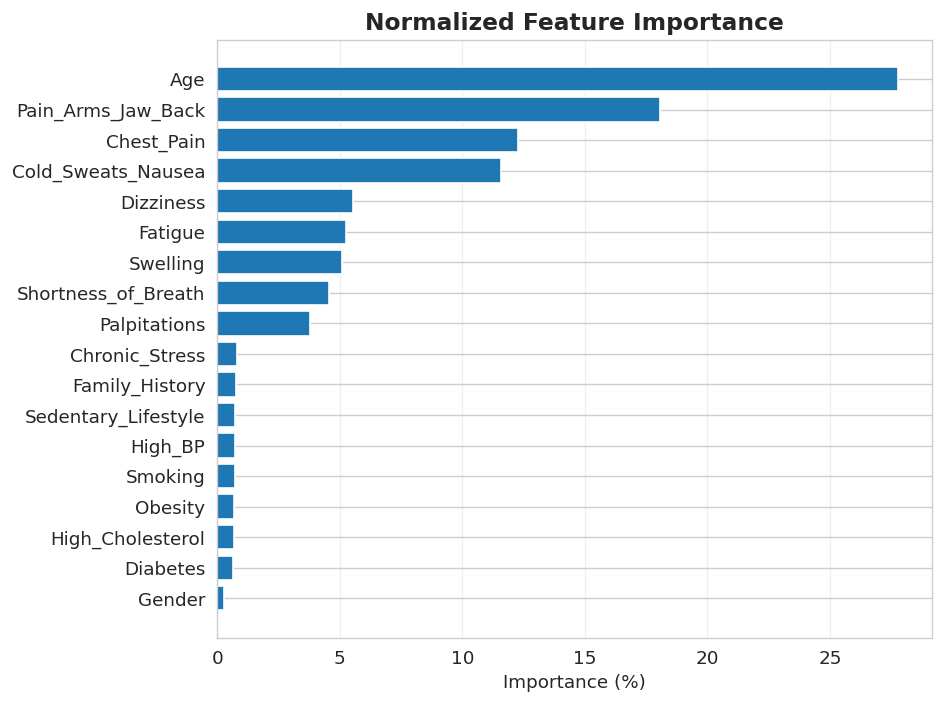

In [17]:
# =====================================================
# Normalized Feature Importance (%)
# =====================================================

importance = best_model.booster_.feature_importance(
    importance_type='gain'
)

importance = importance / importance.sum() * 100

fi = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance (%)": importance
})

fi = fi.sort_values(
    by="Importance (%)",
    ascending=False
)

display(fi)

plt.figure(figsize=(8,6))

plt.barh(
    fi["Feature"],
    fi["Importance (%)"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance (%)")

plt.title(
    "Normalized Feature Importance",
    fontsize=14,
    fontweight='bold'
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

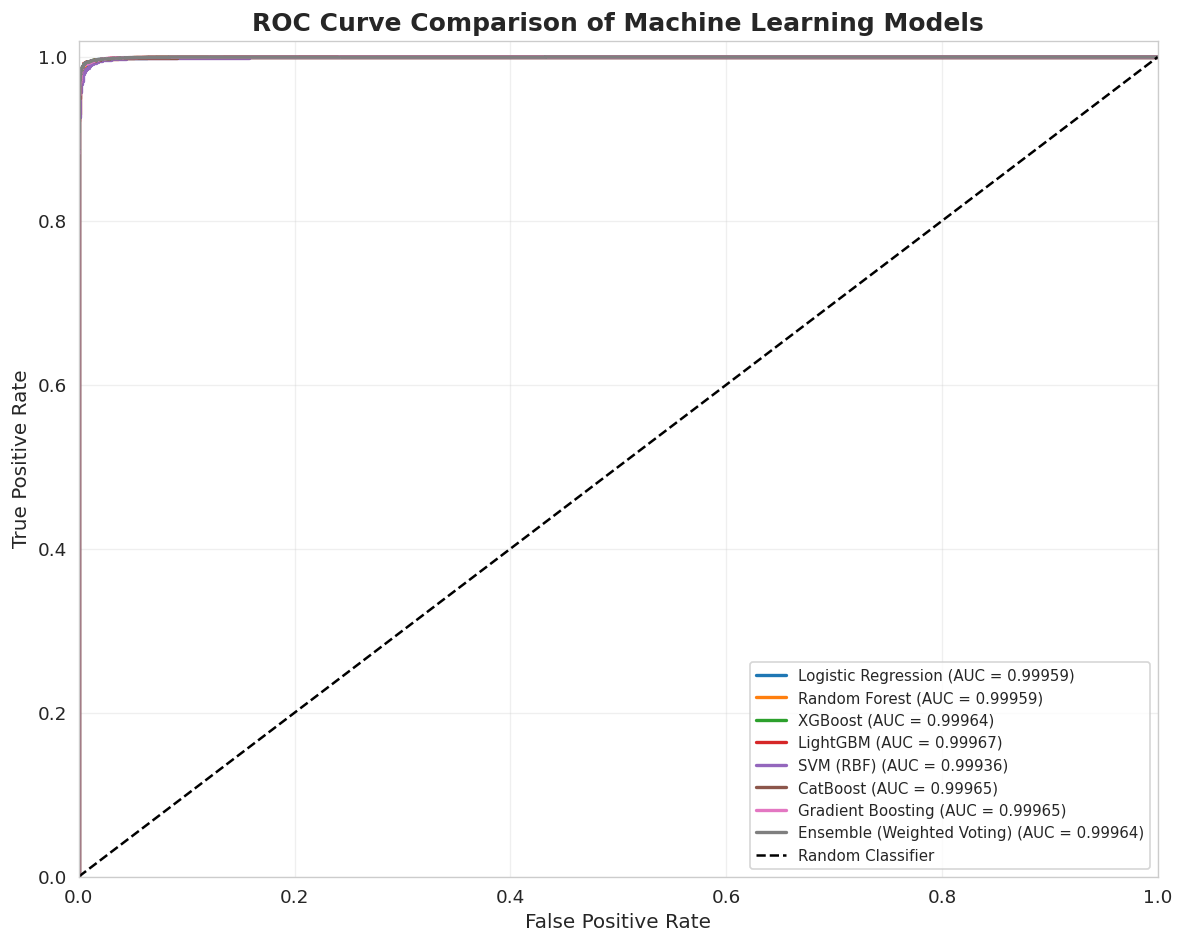

In [ ]:
# ================= ROC CURVE COMPARISON =================


plt.figure(figsize=(10, 8))

for name, model in models.items():

    # Use scaled data for Logistic Regression and SVM
    if name in ["Logistic Regression", "SVM (RBF)"]:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_score:.5f})"
    )

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')

plt.xlim([0, 1])
plt.ylim([0, 1.02])

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison of Machine Learning Models", fontsize=15, fontweight='bold')

plt.legend(loc="lower right", fontsize=9)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

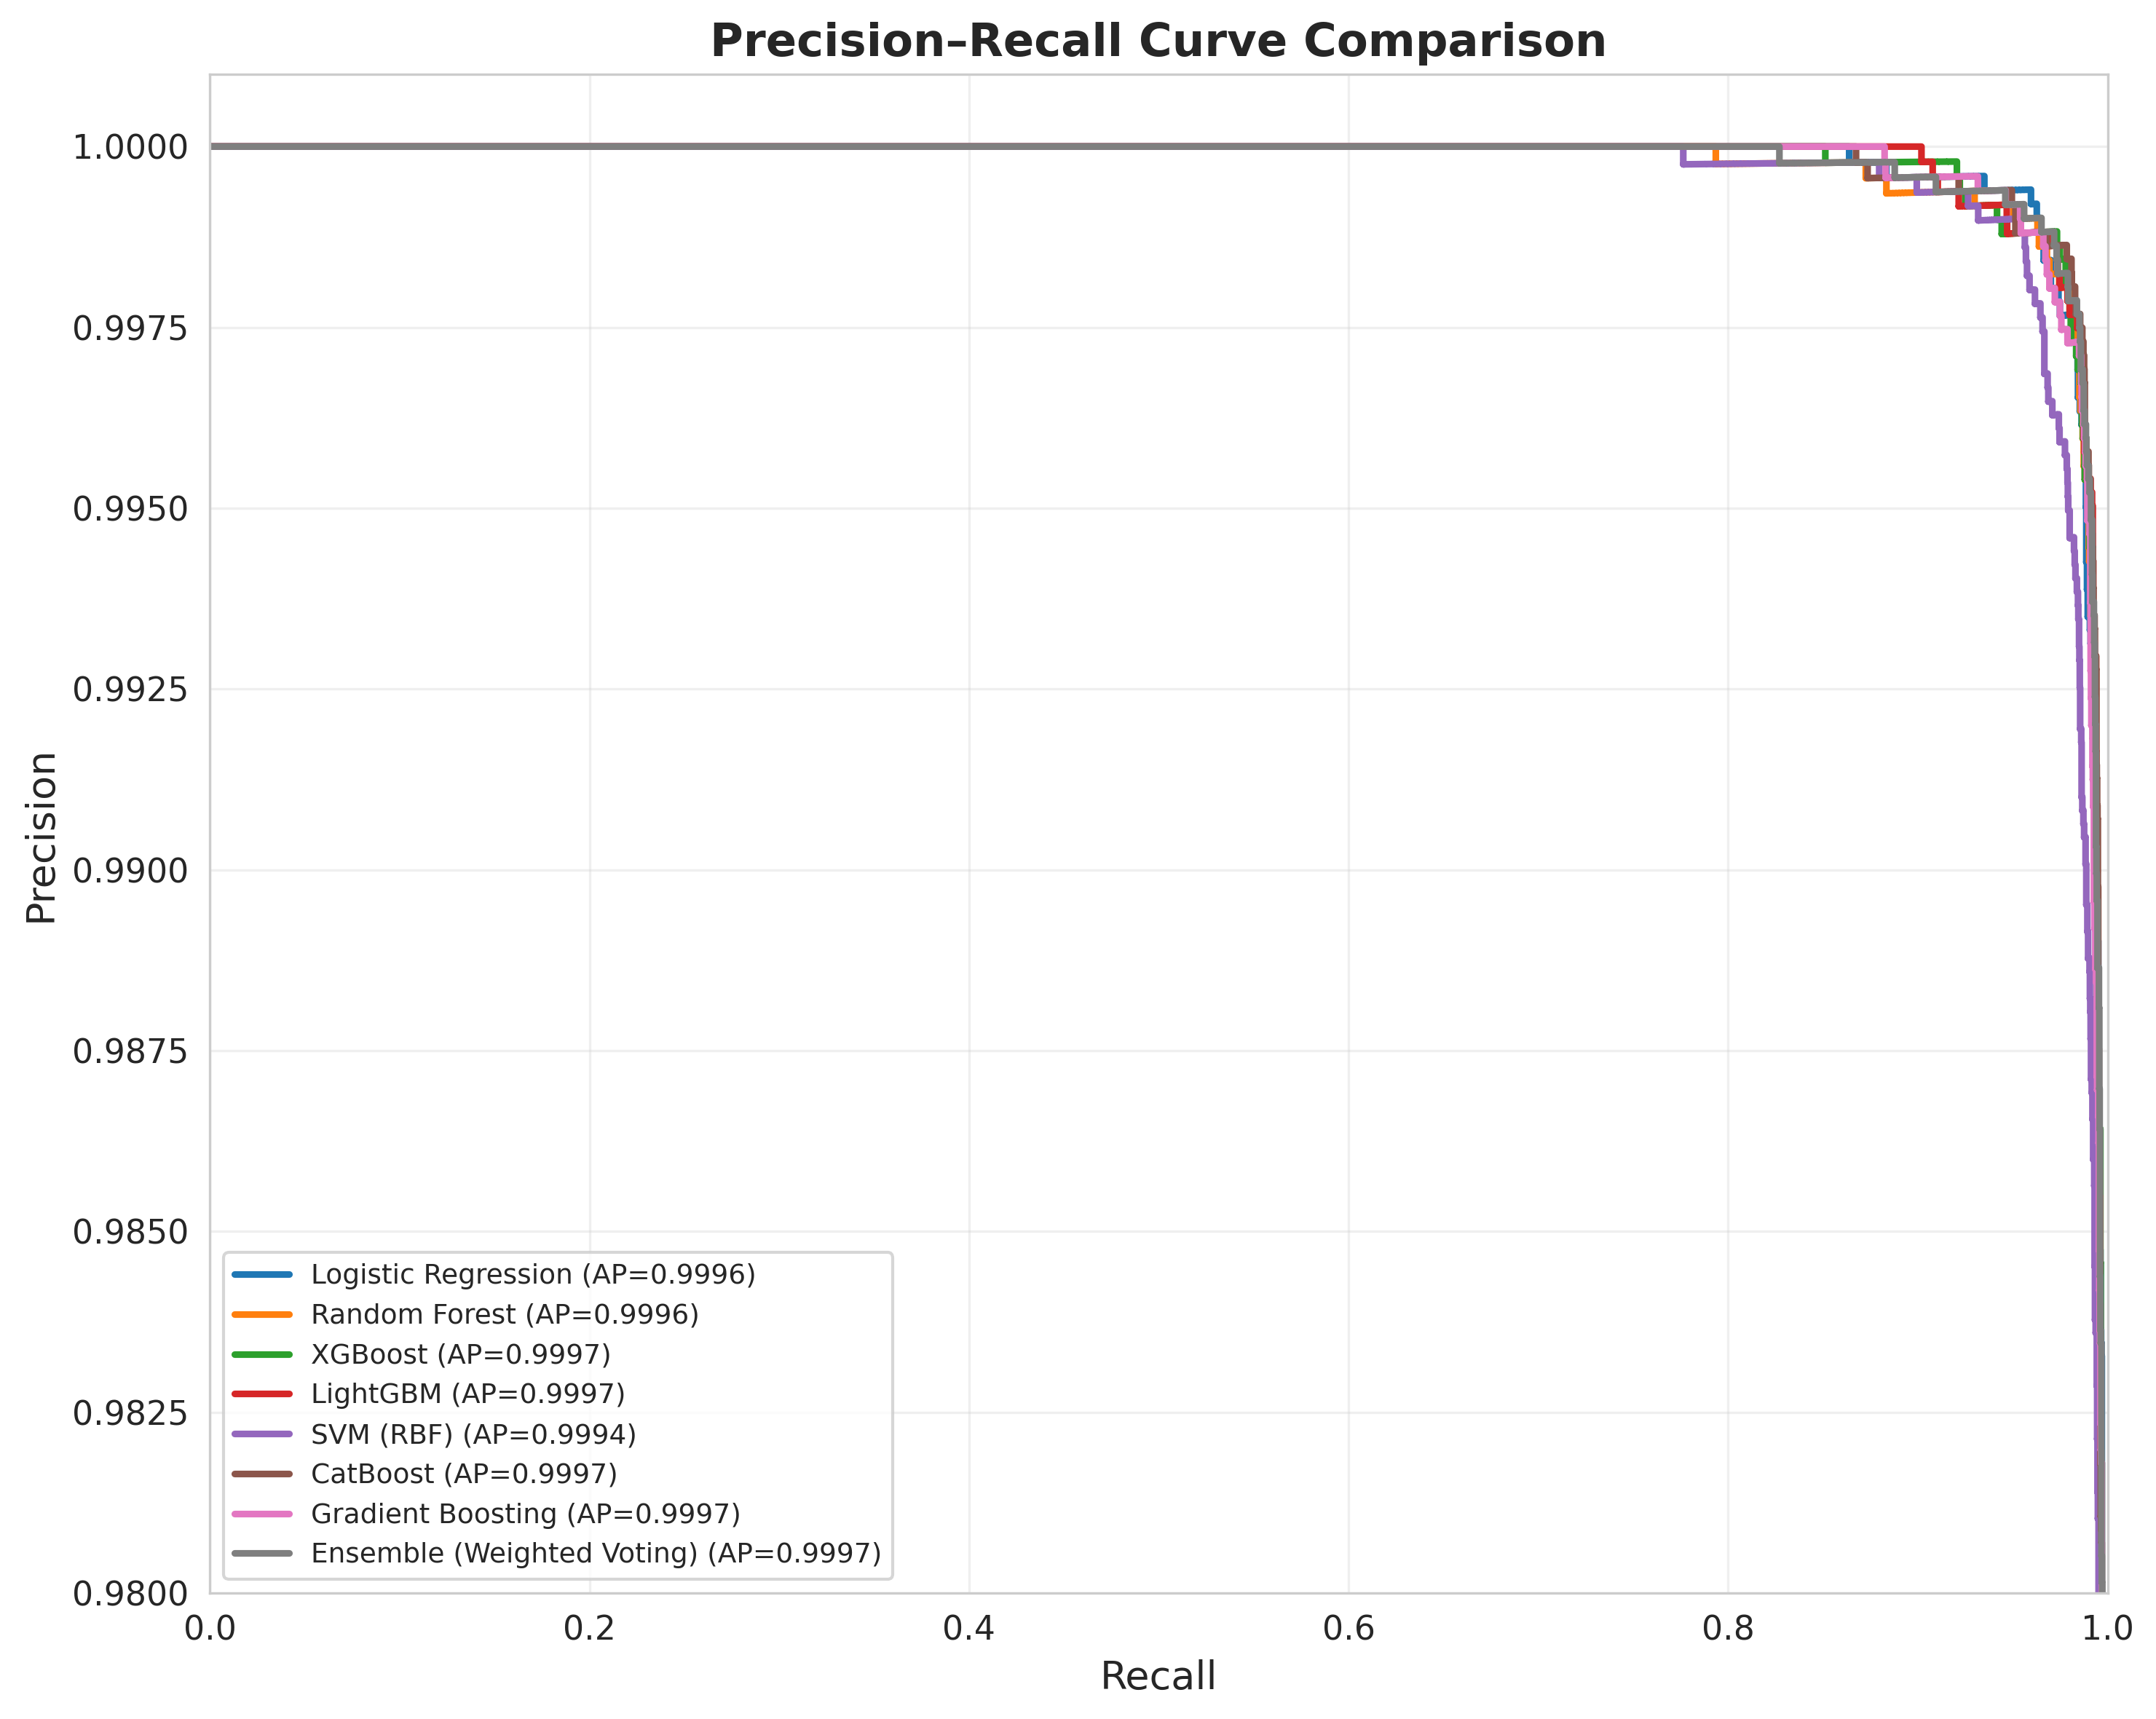

In [ ]:
# ================= Precision-Recall Curve Comparison =================
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


plt.figure(figsize=(10,8), dpi=300)

for name, model in models.items():

    if name in ["Logistic Regression", "SVM (RBF)"]:
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_prob = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    plt.step(
        recall,
        precision,
        where="post",
        linewidth=2.2,
        label=f"{name} (AP={ap:.4f})"
    )

plt.xlim(0,1)
plt.ylim(0.98,1.001)   # Zoom into the top region

plt.xlabel("Recall", fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.title("Precision–Recall Curve Comparison", fontsize=15, weight="bold")

plt.grid(alpha=0.3)
plt.legend(fontsize=9, loc="lower left")

plt.tight_layout()
plt.show()

Logistic Regression


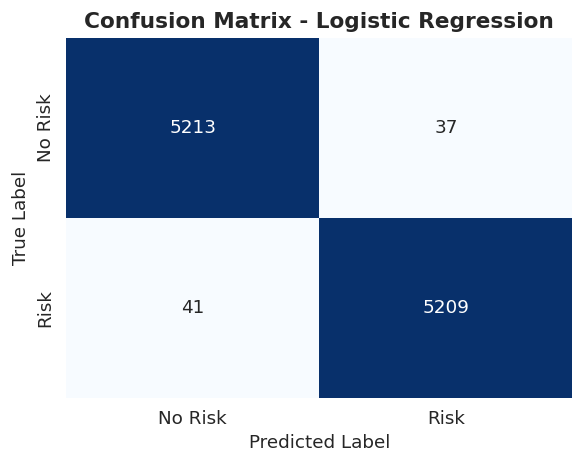


Classification Report

              precision    recall  f1-score   support

     No Risk     0.9922    0.9930    0.9926      5250
        Risk     0.9929    0.9922    0.9926      5250

    accuracy                         0.9926     10500
   macro avg     0.9926    0.9926    0.9926     10500
weighted avg     0.9926    0.9926    0.9926     10500

Random Forest


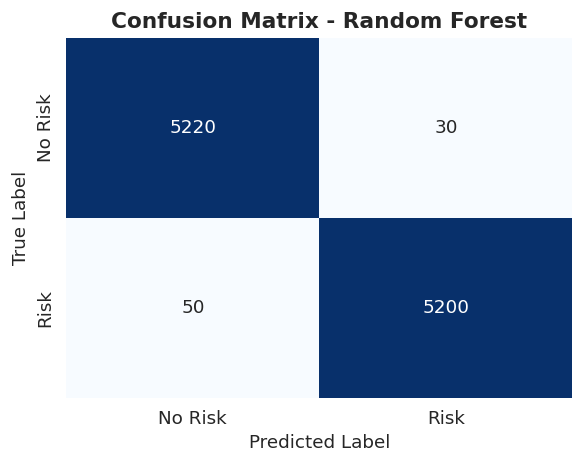


Classification Report

              precision    recall  f1-score   support

     No Risk     0.9905    0.9943    0.9924      5250
        Risk     0.9943    0.9905    0.9924      5250

    accuracy                         0.9924     10500
   macro avg     0.9924    0.9924    0.9924     10500
weighted avg     0.9924    0.9924    0.9924     10500

XGBoost


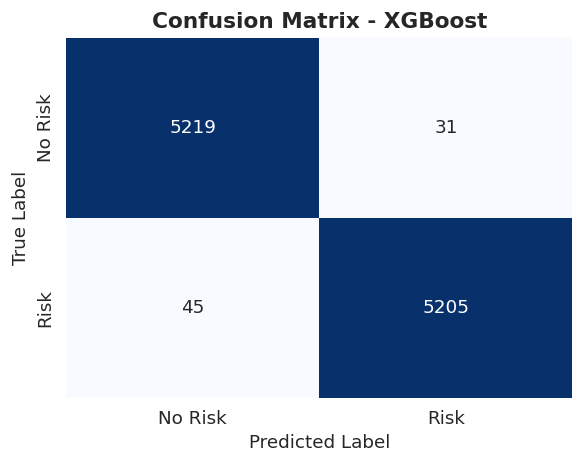


Classification Report

              precision    recall  f1-score   support

     No Risk     0.9915    0.9941    0.9928      5250
        Risk     0.9941    0.9914    0.9928      5250

    accuracy                         0.9928     10500
   macro avg     0.9928    0.9928    0.9928     10500
weighted avg     0.9928    0.9928    0.9928     10500

LightGBM


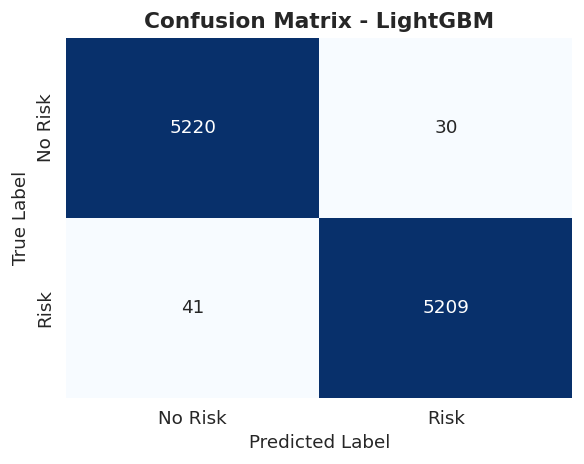


Classification Report

              precision    recall  f1-score   support

     No Risk     0.9922    0.9943    0.9932      5250
        Risk     0.9943    0.9922    0.9932      5250

    accuracy                         0.9932     10500
   macro avg     0.9932    0.9932    0.9932     10500
weighted avg     0.9932    0.9932    0.9932     10500

SVM (RBF)


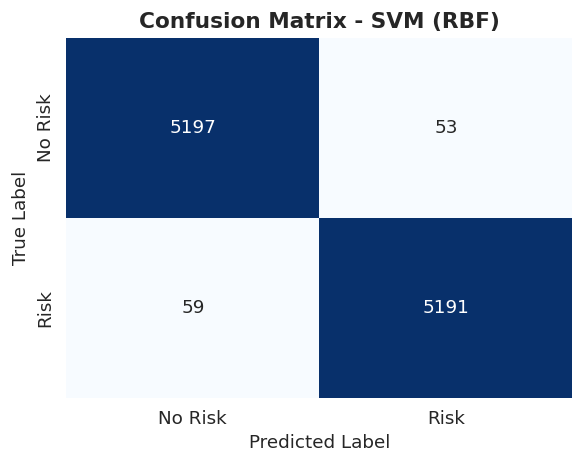


Classification Report

              precision    recall  f1-score   support

     No Risk     0.9888    0.9899    0.9893      5250
        Risk     0.9899    0.9888    0.9893      5250

    accuracy                         0.9893     10500
   macro avg     0.9893    0.9893    0.9893     10500
weighted avg     0.9893    0.9893    0.9893     10500

CatBoost


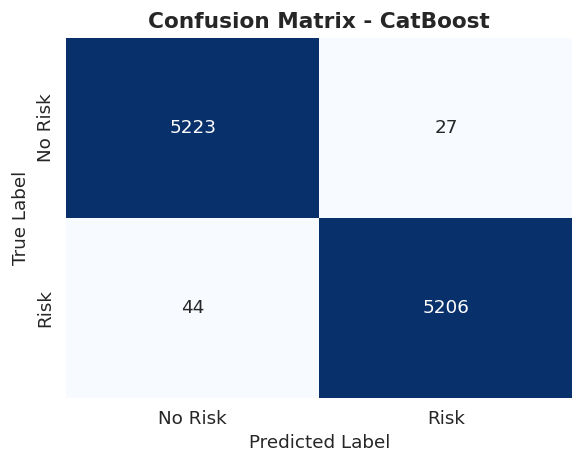


Classification Report

              precision    recall  f1-score   support

     No Risk     0.9916    0.9949    0.9932      5250
        Risk     0.9948    0.9916    0.9932      5250

    accuracy                         0.9932     10500
   macro avg     0.9932    0.9932    0.9932     10500
weighted avg     0.9932    0.9932    0.9932     10500

Gradient Boosting


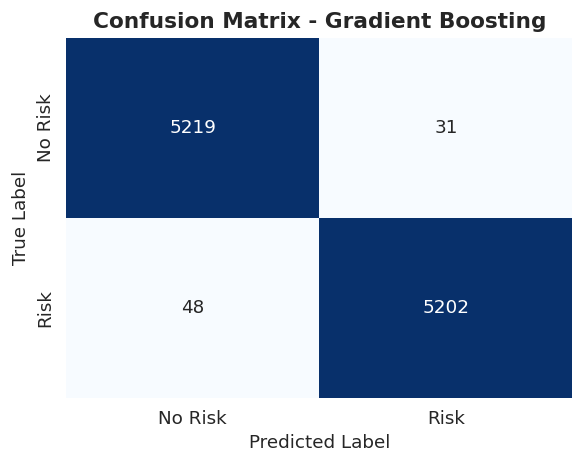


Classification Report

              precision    recall  f1-score   support

     No Risk     0.9909    0.9941    0.9925      5250
        Risk     0.9941    0.9909    0.9925      5250

    accuracy                         0.9925     10500
   macro avg     0.9925    0.9925    0.9925     10500
weighted avg     0.9925    0.9925    0.9925     10500

Ensemble (Weighted Voting)


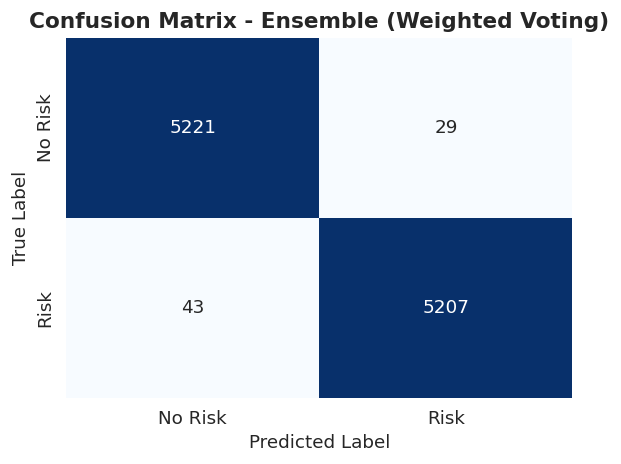


Classification Report

              precision    recall  f1-score   support

     No Risk     0.9918    0.9945    0.9932      5250
        Risk     0.9945    0.9918    0.9931      5250

    accuracy                         0.9931     10500
   macro avg     0.9931    0.9931    0.9931     10500
weighted avg     0.9931    0.9931    0.9931     10500



In [ ]:
# ================= CONFUSION MATRIX & CLASSIFICATION REPORT =================

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():

    print("="*80)
    print(f"{name}")
    print("="*80)

    # Use scaled data for Logistic Regression and SVM
    if name in ["Logistic Regression", "SVM (RBF)"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=["No Risk", "Risk"],
        yticklabels=["No Risk", "Risk"]
    )

    plt.title(f"Confusion Matrix - {name}", fontsize=13, fontweight="bold")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    # Classification Report
    print("\nClassification Report\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Risk", "Risk"],
        digits=4
    ))

In [ ]:
# ================= McNemar Statistical Test =================

from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd

best_model_name = "LightGBM"

# Prediction from best model
best_pred = models[best_model_name].predict(X_test)

results = []

for name, model in models.items():

    if name == best_model_name:
        continue

    if name in ["Logistic Regression", "SVM (RBF)"]:
        pred = model.predict(X_test_scaled)
    else:
        pred = model.predict(X_test)

    # Correct / incorrect
    best_correct = (best_pred == y_test)
    other_correct = (pred == y_test)

    # McNemar contingency table
    b = ((best_correct == True) & (other_correct == False)).sum()
    c = ((best_correct == False) & (other_correct == True)).sum()

    table = [[0, b],
             [c, 0]]

    result = mcnemar(table, exact=False, correction=True)

    results.append({
        "Comparison": f"{best_model_name} vs {name}",
        "Statistic": result.statistic,
        "P-value": result.pvalue
    })

mcnemar_df = pd.DataFrame(results)

print("="*70)
print("McNemar Statistical Test")
print("="*70)

display(mcnemar_df)

McNemar Statistical Test


,Comparison,Statistic,P-value
0,LightGBM vs Logistic Regression,0.679245,4.098467e-01
1,LightGBM vs Random Forest,1.488372,2.224692e-01
2,LightGBM vs XGBoost,0.941176,3.319755e-01
3,LightGBM vs SVM (RBF),24.615385,6.999072e-07
4,LightGBM vs CatBoost,0.055556,8.136637e-01
5,LightGBM vs Gradient Boosting,2.450000,1.175249e-01
6,LightGBM vs Ensemble (Weighted Voting),0.000000,1.000000e+00


In [ ]:
print("="*70)
print("Interpretation")
print("="*70)

for _, row in mcnemar_df.iterrows():

    if row["P-value"] < 0.05:
        print(f"{row['Comparison']}: Significant Difference (p = {row['P-value']:.4f})")
    else:
        print(f"{row['Comparison']}: No Significant Difference (p = {row['P-value']:.4f})")

Interpretation
LightGBM vs Logistic Regression: No Significant Difference (p = 0.4098)
LightGBM vs Random Forest: No Significant Difference (p = 0.2225)
LightGBM vs XGBoost: No Significant Difference (p = 0.3320)
LightGBM vs SVM (RBF): Significant Difference (p = 0.0000)
LightGBM vs CatBoost: No Significant Difference (p = 0.8137)
LightGBM vs Gradient Boosting: No Significant Difference (p = 0.1175)
LightGBM vs Ensemble (Weighted Voting): No Significant Difference (p = 1.0000)


McNemar's test was performed to compare the classification performance of the proposed LightGBM model with the competing machine learning models. No statistically significant differences (p > 0.05) were observed between LightGBM and the other tree-based models, Logistic Regression, or the ensemble model, indicating comparable classification performance. A statistically significant difference was observed only between LightGBM and the SVM model (p < 0.001). Although the top-performing models achieved statistically comparable classification accuracy, LightGBM consistently achieved the highest ROC-AUC and was therefore selected as the final model for calibration, explainability, and fairness analysis.

In [ ]:
# Best model (LightGBM)

y_pred_lgb = lgb_model.predict(X_test)

y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

In [ ]:
# ================= FAIRNESS ANALYSIS =================

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

def fairness_analysis(X_test, y_test, y_prob, sensitive_col):

    df = X_test.copy()

    df["True"] = y_test.values
    df["Pred_Prob"] = y_prob
    df["Pred"] = (y_prob >= 0.5).astype(int)

    results = []

    # Positive prediction rate of reference group
    positive_rates = {}

    for group_name, group in df.groupby(sensitive_col):

        tn, fp, fn, tp = confusion_matrix(
            group["True"],
            group["Pred"],
            labels=[0,1]
        ).ravel()

        positive_rate = group["Pred"].mean()

        tpr = tp/(tp+fn) if (tp+fn)>0 else 0

        fpr = fp/(fp+tn) if (fp+tn)>0 else 0

        positive_rates[group_name] = positive_rate

        results.append({

            "Group": group_name,

            "Samples": len(group),

            "Positive Rate": positive_rate,

            "True Positive Rate": tpr,

            "False Positive Rate": fpr

        })

    fairness_df = pd.DataFrame(results)

    # Reference group = first row
    reference = fairness_df.iloc[0]["Positive Rate"]

    fairness_df["Demographic Parity Difference"] = (
        fairness_df["Positive Rate"] - reference
    )

    fairness_df["Disparate Impact"] = (
        fairness_df["Positive Rate"] / reference
    )

    ref_tpr = fairness_df.iloc[0]["True Positive Rate"]

    fairness_df["Equal Opportunity Difference"] = (
        fairness_df["True Positive Rate"] - ref_tpr
    )

    ref_fpr = fairness_df.iloc[0]["False Positive Rate"]

    fairness_df["Equalized Odds Difference"] = (
        (fairness_df["True Positive Rate"]-ref_tpr).abs() +
        (fairness_df["False Positive Rate"]-ref_fpr).abs()
    )

    return fairness_df.round(4)

In [ ]:
gender_results = fairness_analysis(
    X_test,
    y_test,
    y_prob_lgb,
    "Gender"
)

print(gender_results)

   Group  Samples  Positive Rate  True Positive Rate  False Positive Rate  \
0    0.0     4831         0.3465              0.9899               0.0044   
1    1.0     5669         0.6289              0.9933               0.0076   

   Demographic Parity Difference  Disparate Impact  \
0                         0.0000            1.0000   
1                         0.2823            1.8148   

   Equal Opportunity Difference  Equalized Odds Difference  
0                        0.0000                     0.0000  
1                        0.0034                     0.0066  


In [ ]:
X_test_age = X_test.copy()

X_test_age["Age_Group"] = pd.cut(
    X_test_age["Age"],
    bins=[0,30,45,60,75,100],
    labels=["<30","30-45","46-60","61-75",">75"]
)

print("========== Age Group Fairness ==========")

age_results = fairness_analysis(
    X_test_age,
    y_test,
    y_prob_lgb,
    "Age_Group"
)

print(age_results)

========== Age Group Fairness ==========
   Group  Samples  Positive Rate  True Positive Rate  False Positive Rate  \
0    <30     1175         0.0000              0.0000               0.0000   
1  30-45     1701         0.0782              0.9925               0.0000   
2  46-60     3506         0.5516              0.9876               0.0121   
3  61-75     2938         0.6780              0.9920               0.0117   
4    >75     1180         1.0000              1.0000               0.0000   

   Demographic Parity Difference  Disparate Impact  \
0                         0.0000               NaN   
1                         0.0782               inf   
2                         0.5516               inf   
3                         0.6780               inf   
4                         1.0000               inf   

   Equal Opportunity Difference  Equalized Odds Difference  
0                        0.0000                     0.0000  
1                        0.9925                  

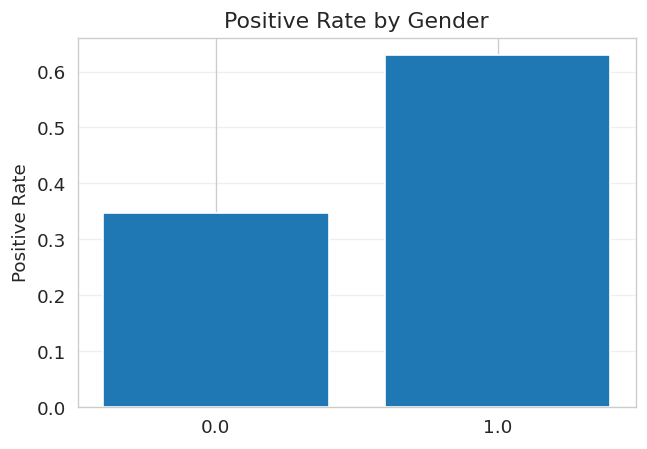

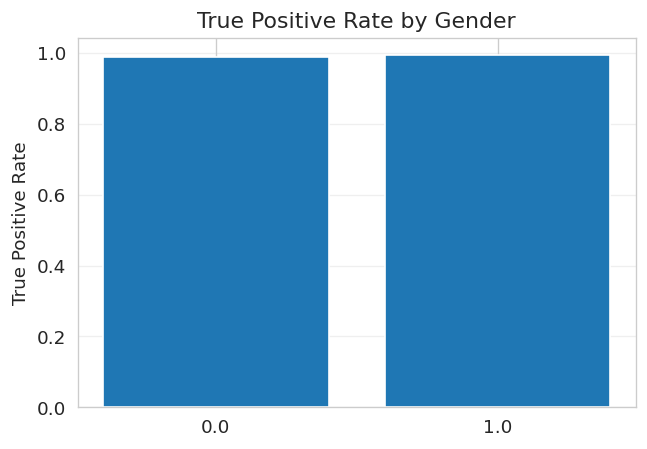

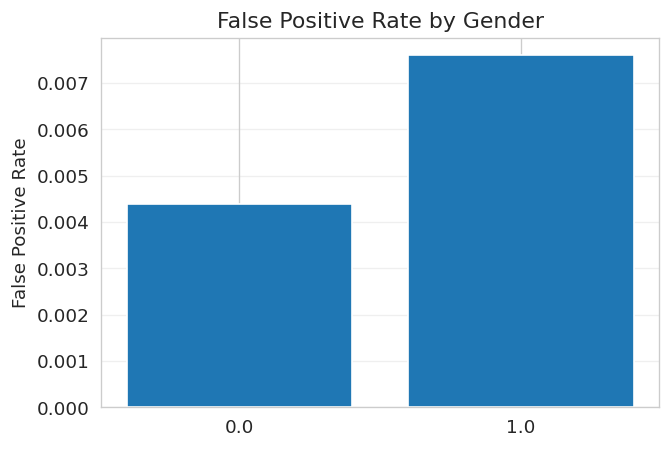

In [ ]:
import matplotlib.pyplot as plt

metrics = [
    "Positive Rate",
    "True Positive Rate",
    "False Positive Rate"
]

for metric in metrics:

    plt.figure(figsize=(6,4))

    plt.bar(
        gender_results["Group"].astype(str),
        gender_results[metric]
    )

    plt.ylabel(metric)

    plt.title(metric + " by Gender")

    plt.grid(axis='y', alpha=0.3)

    plt.show()

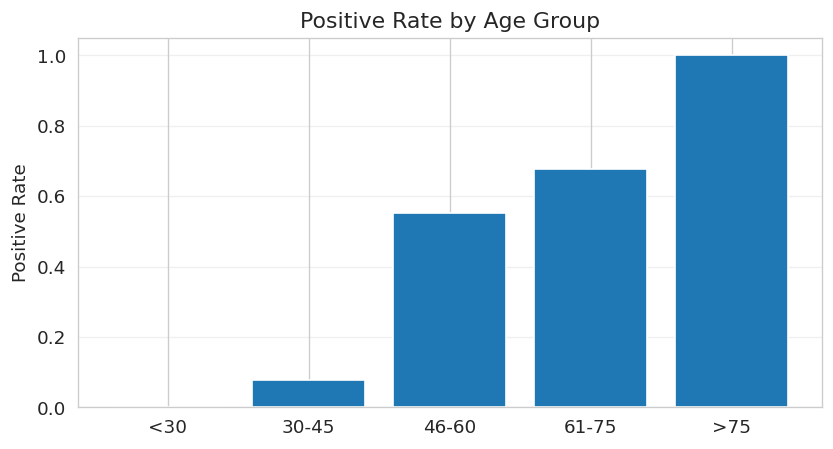

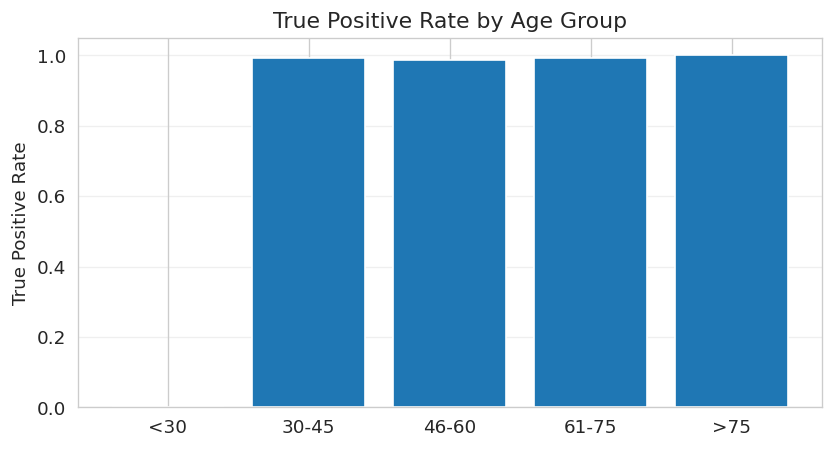

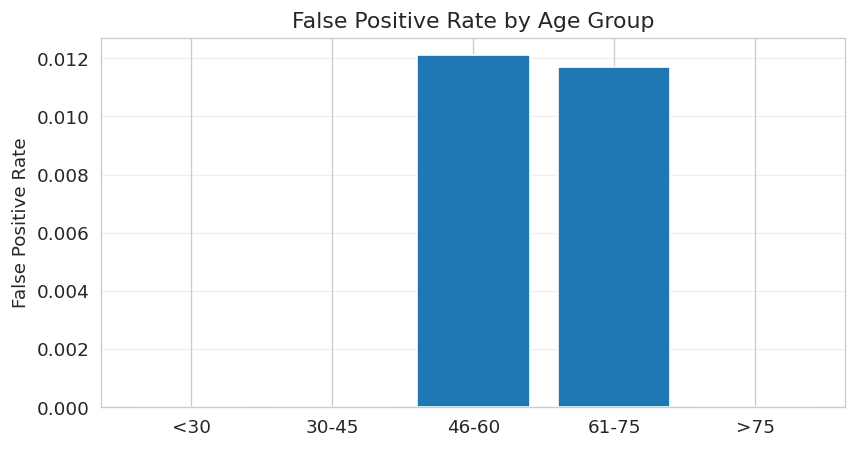

In [ ]:
for metric in metrics:

    plt.figure(figsize=(8,4))

    plt.bar(
        age_results["Group"].astype(str),
        age_results[metric]
    )

    plt.ylabel(metric)

    plt.title(metric + " by Age Group")

    plt.grid(axis='y', alpha=0.3)

    plt.show()

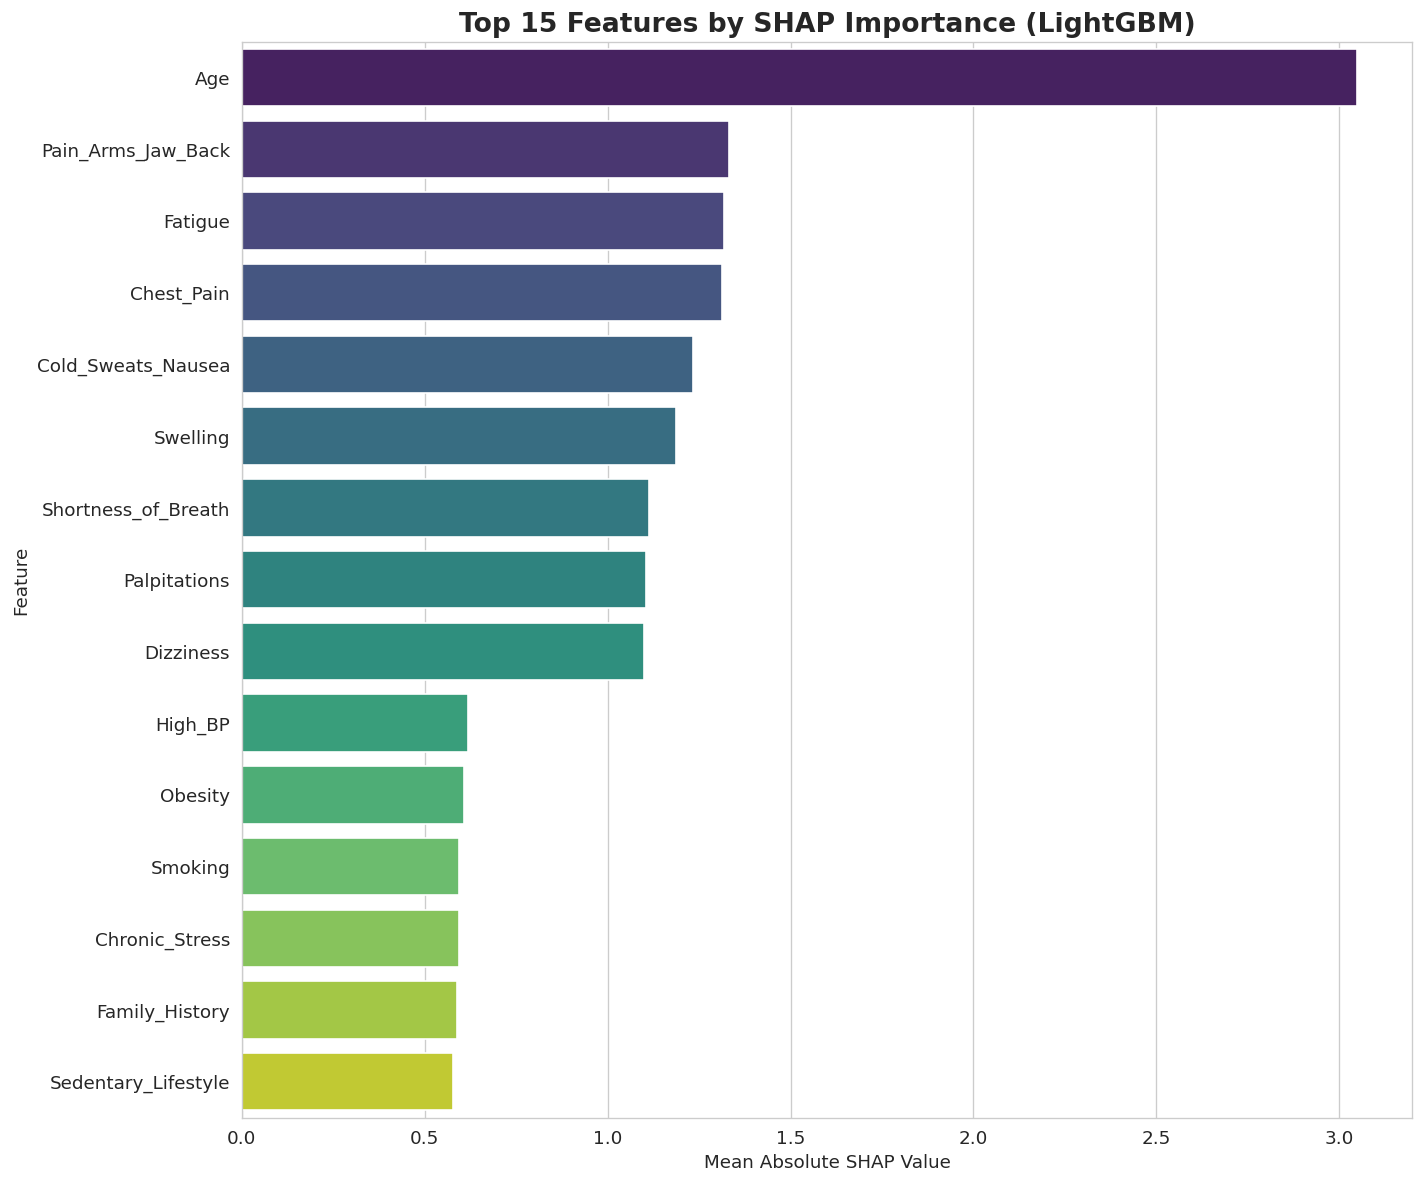

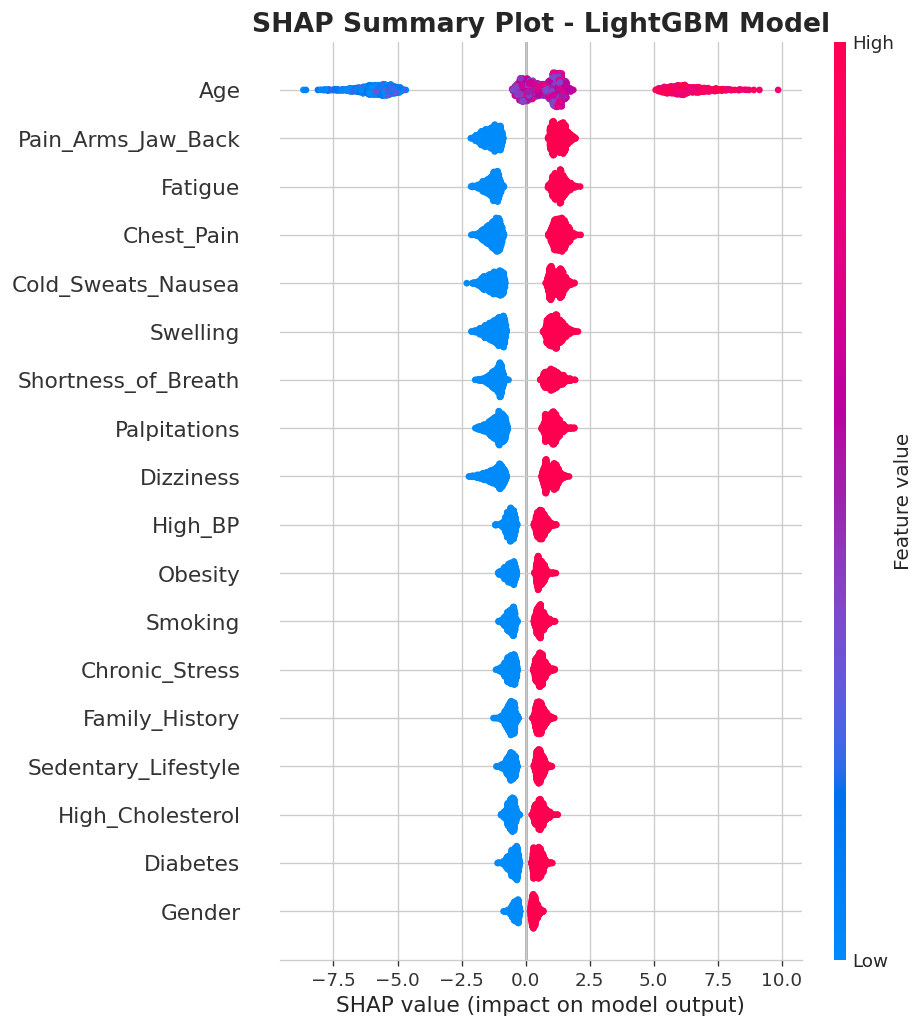

In [ ]:
# ==================== SHAP ANALYSIS USING LIGHTGBM ====================
import shap

# Use LightGBM model for SHAP
explainer = shap.TreeExplainer(lgb_model)

# Sample for faster computation
np.random.seed(42)
X_sample = X_test.sample(2000, random_state=42)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Top 15 Features Bar Plot
shap_imp = pd.DataFrame({
    'Feature': X.columns,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Mean_Abs_SHAP', y='Feature', data=shap_imp.head(15), palette='viridis')
plt.title('Top 15 Features by SHAP Importance (LightGBM)', fontsize=16, fontweight='bold')
plt.xlabel('Mean Absolute SHAP Value')
plt.tight_layout()
plt.show()

# SHAP Summary Plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, plot_type="dot", show=False)
plt.title('SHAP Summary Plot - LightGBM Model', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ==================== UNCERTAINTY QUANTIFICATION ====================

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Create Calibrated Version of LightGBM (Best Model)
print("Training Calibrated LightGBM for Better Uncertainty...")

calibrated_lgb = CalibratedClassifierCV(
    estimator=lgb_model,
    cv=5,
    method='isotonic'   # Best for medical data
)

calibrated_lgb.fit(X_train, y_train)

# Get calibrated predictions
y_prob_calibrated = calibrated_lgb.predict_proba(X_test)[:, 1]
y_pred_calibrated = calibrated_lgb.predict(X_test)

print("=== Calibrated LightGBM Performance ===")
print("Accuracy :", accuracy_score(y_test, y_pred_calibrated))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_calibrated))

Training Calibrated LightGBM for Better Uncertainty...
=== Calibrated LightGBM Performance ===
Accuracy : 0.9930476190476191
ROC-AUC  : 0.9996154195011338


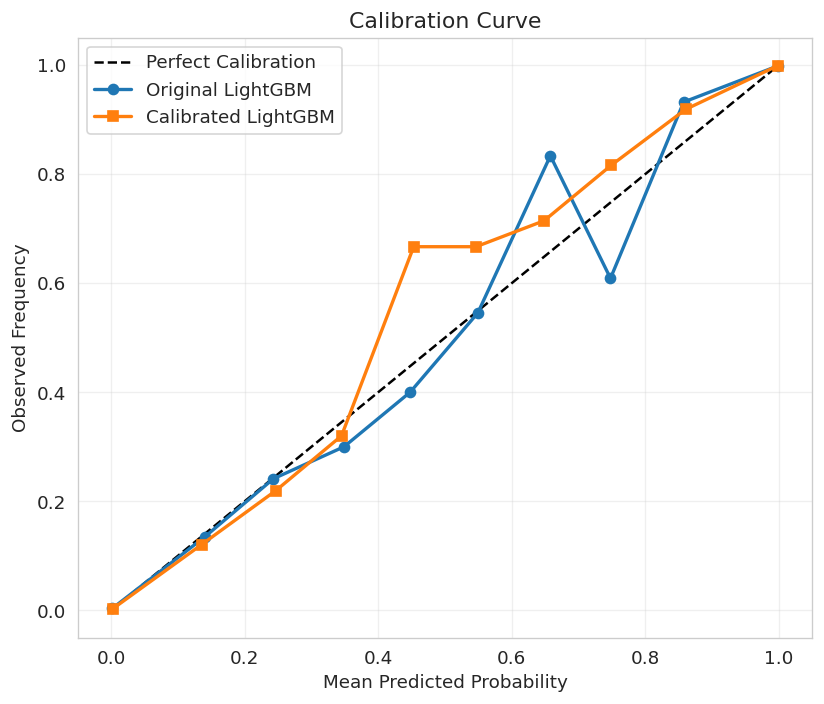

Original Brier Score   : 0.005532457132292554
Calibrated Brier Score : 0.0054466615758097785


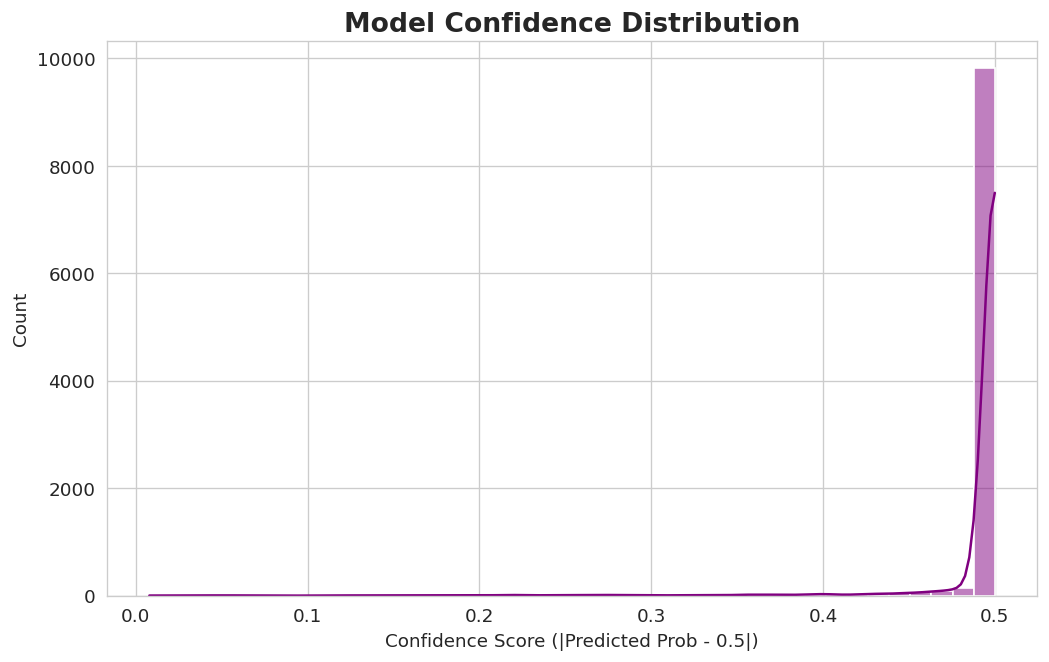

In [ ]:
# ==================== CALIBRATION CURVE ====================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Original LightGBM probabilities
y_prob_original = lgb_model.predict_proba(X_test)[:, 1]

# Calibration curves
prob_true_orig, prob_pred_orig = calibration_curve(
    y_test,
    y_prob_original,
    n_bins=10,
    strategy='uniform'
)

prob_true_cal, prob_pred_cal = calibration_curve(
    y_test,
    y_prob_calibrated,
    n_bins=10,
    strategy='uniform'
)

plt.figure(figsize=(7,6))

# Perfect calibration
plt.plot([0,1],[0,1],'k--',label='Perfect Calibration')

# Original model
plt.plot(
    prob_pred_orig,
    prob_true_orig,
    marker='o',
    linewidth=2,
    label='Original LightGBM'
)

# Calibrated model
plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker='s',
    linewidth=2,
    label='Calibrated LightGBM'
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Brier Scores
print("Original Brier Score   :", brier_score_loss(y_test, y_prob_original))
print("Calibrated Brier Score :", brier_score_loss(y_test, y_prob_calibrated))

#Model Confidence Distribution
confidence = np.abs(y_prob_calibrated - 0.5)

plt.figure(figsize=(10, 6))
sns.histplot(confidence, bins=40, kde=True, color='purple')
plt.title('Model Confidence Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Confidence Score (|Predicted Prob - 0.5|)')
plt.ylabel('Count')
plt.show()